# Tutorial 5.3: Enrichment Analysis of PRISM-Imputed Dopamine-DD in Human PD Brain

This downstream analysis interprets PRISM raw-scale Dopamine-DD predictions at metabolite-unregistered RNA locations across the A1, B1 and C1 PD striatum sections. It should be run after Tutorial 5.2 has generated the missing-location prediction file for each section.

The predicted Dopamine-DD signal defines response and silent analysis strata, which are linked to RNA from the same locations for differential-expression and pathway analyses. These are model-informed association groups, not ground-truth dopamine calls or cell annotations.


In [1]:
import subprocess
import tempfile
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import Image, display
warnings.filterwarnings("ignore")
import PRISM
from PRISM import (assign_dopamine_status, load_imputed_dopamine_predictions, plot_dopamine_distribution,
                   plot_pd_human_volcano, run_imputed_dopamine_deg, set_prism_plot_style)
set_prism_plot_style()

### Configure multi-slice analysis

`SLICE_IDS` selects the prepared A1, B1 and C1 sections. Their missing-location PRISM predictions and matched RNA profiles are combined with slice identity retained, while significant-gene tables and enrichment gene lists are written to `ENRICHMENT_DIR`.


In [2]:
# Configure multi-slice PD striatum inputs
SLICE_IDS = ("A1", "B1", "C1")
DOPAMINE_FEATURE = "Dopamine_DD"
DATA_ROOT = Path("Datasets") / "PD human brain"
RESULTS_ROOT = Path("Results") / "Tutorial5_2_PD_human_brain"
ENRICHMENT_DIR = RESULTS_ROOT / "Enrichment analysis"
ENRICHMENT_DIR.mkdir(parents=True, exist_ok=True)
RNA_PATHS = {slice_id: DATA_ROOT / slice_id / f"{slice_id}_RNA.h5ad" for slice_id in SLICE_IDS}
PREDICTION_PATHS = {slice_id: RESULTS_ROOT / slice_id / f"{slice_id}_PD_human_PRISM_raw_pred.csv"
                    for slice_id in SLICE_IDS}
GENE_LIST_PATHS = {"Dopamine_response": ENRICHMENT_DIR / "Dopamine_response_top100_genes_for_enrichment.txt",
                   "Dopamine_silent": ENRICHMENT_DIR / "Dopamine_silent_top100_genes_for_enrichment.txt"}
R_ENRICHMENT_SCRIPT = Path(PRISM.__file__).resolve().parent / "enrichment.R"
RSCRIPT = "Rscript"

### Load and stratify imputed Dopamine-DD

Tutorial 5.2 provides raw-scale Dopamine-DD predictions only for RNA locations without a retained MSI partner. After pooling sections with slice-prefixed barcodes, a two-component Gaussian mixture is fitted to the log-transformed predictions; its midpoint defines `Dopamine_response` and `Dopamine_silent` for downstream RNA association.


,method,threshold_raw
0,median,8.263468e+05
1,q75,1.970860e+06
2,q80,2.224267e+06
3,GMM_midpoint,5.491482e+05


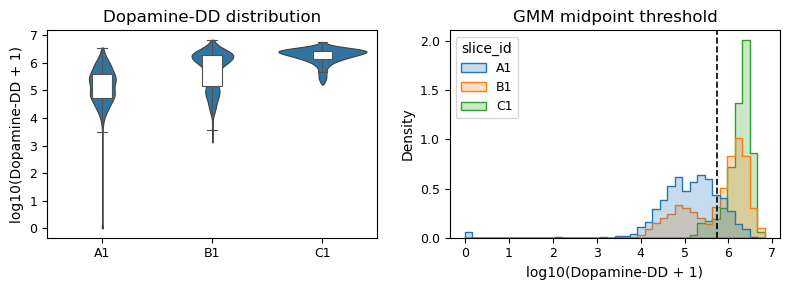

In [3]:
# Load imputed Dopamine-DD profiles
dopamine_df = load_imputed_dopamine_predictions(PREDICTION_PATHS, SLICE_IDS, feature_name=DOPAMINE_FEATURE)

# Define model-derived Dopamine-DD strata and display their distribution
dopamine_df, threshold_table, dopamine_threshold = assign_dopamine_status(dopamine_df, feature_name=DOPAMINE_FEATURE,
                                                                          threshold_method="GMM_midpoint")
fig, _ = plot_dopamine_distribution(dopamine_df, dopamine_threshold, feature_name=DOPAMINE_FEATURE)
display(threshold_table)

### RNA associations with PRISM-derived Dopamine-DD status

RNA profiles from the predicted locations are pooled across the three sections and compared between the response and silent strata using a Wilcoxon test. Significant group-enriched genes are prioritized into separate top-100 gene lists for pathway analysis, and the volcano plot displays the response-versus-silent association.


In [6]:
# Identify RNA associations with PRISM-derived Dopamine-DD status
deg_results, significant_results, top_gene_sets = run_imputed_dopamine_deg(RNA_PATHS, SLICE_IDS, dopamine_df,
                                                                           output_dir=ENRICHMENT_DIR, 
                                                                           gene_list_paths=GENE_LIST_PATHS, 
                                                                           top_k=100, padj_cutoff=0.05)

selected_gene_table = pd.DataFrame({group_name: pd.Series(genes) for group_name, genes in top_gene_sets.items()})
display(selected_gene_table)

,Dopamine_response,Dopamine_silent
0,NCDN,TF
1,SCG2,PLP1
2,THY1,MBP
3,SYNPR,CRYAB
4,ARPP21,EFHD1
...,...,...
95,CACNA1E,RFFL
96,IDS,BOK
97,PCP4L1,GJC2
98,YPEL1,ZDHHC9


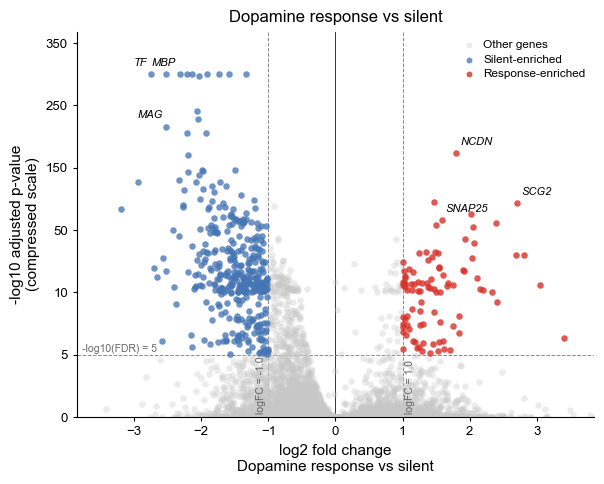

In [14]:
# Select gene symbols to annotate on the volcano plot
VOLCANO_LABEL_GENES = {"Dopamine_response": ("NCDN", "SNAP25", "SCG2"),
                       "Dopamine_silent": ("MAG", "TF", "MBP")}

# Display the Dopamine-response versus Dopamine-silent volcano plot
fig, _ = plot_pd_human_volcano(deg_results["Dopamine_response"], label_genes=VOLCANO_LABEL_GENES)

### KEGG pathway enrichment

The two group-enriched gene lists are mapped to Entrez identifiers and tested against the current human [KEGG](https://www.genome.jp/kegg/) pathway annotations. The comparison plot summarizes FDR-significant pathways for the response and silent strata, with point size denoting gene overlap and colour denoting enrichment significance.


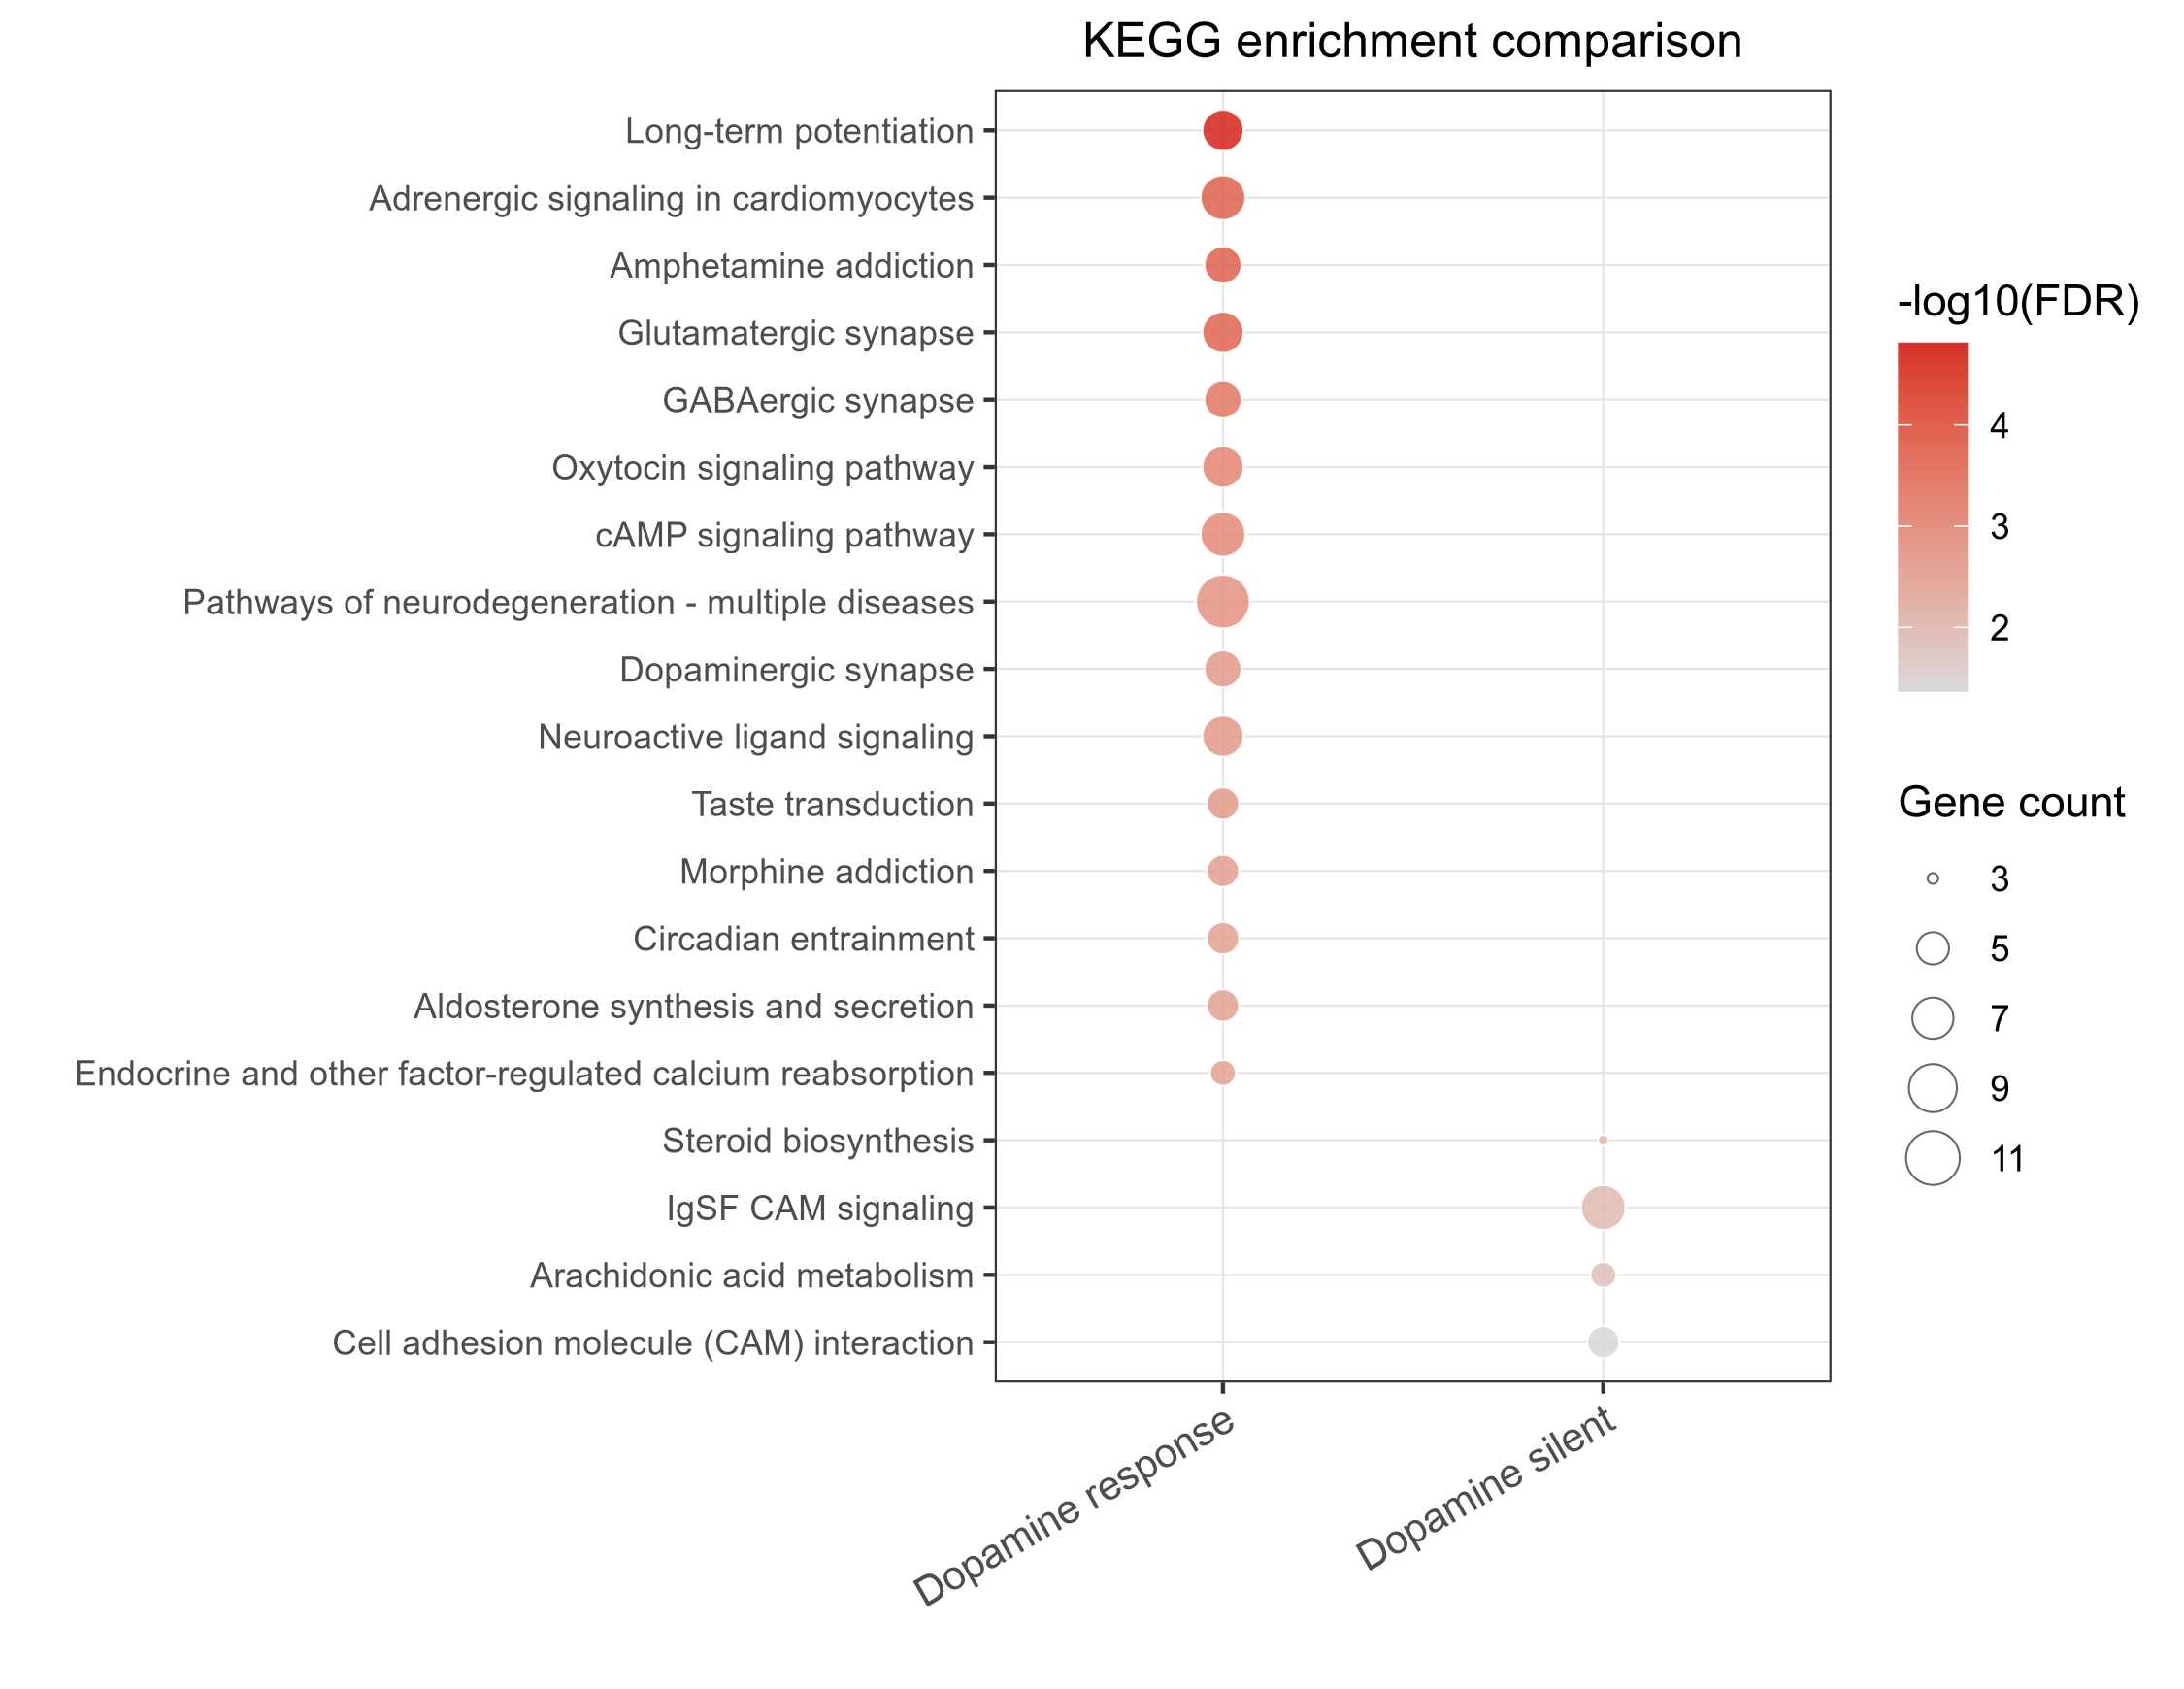

In [5]:
# Run KEGG enrichment and display the cross-group comparison
with tempfile.TemporaryDirectory(prefix="prism_pd_enrichment_") as plot_dir:
    r_result = subprocess.run([str(RSCRIPT), str(R_ENRICHMENT_SCRIPT),
        str(GENE_LIST_PATHS["Dopamine_response"]), str(GENE_LIST_PATHS["Dopamine_silent"]), plot_dir],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    if r_result.returncode != 0:
        raise RuntimeError("KEGG enrichment failed. Last R log lines:\n" + r_result.stdout[-12000:])
    display(Image(filename=str(Path(plot_dir) / "KEGG_comparison.png")))